# 01. Multiple Regression: The Big Picture

Simple linear regression explains a response with one predictor. Multiple linear regression explains a response with two or more predictors at the same time.

In this module, the response is `Sales`, and the predictors are advertising spending in two channels: `RadioSpend` and `PrintSpend`. The goal is not only to predict sales. The goal is to learn how much each channel contributes after accounting for the other channel.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True


Running outside JupyterLite; assuming packages are already installed.


In [2]:
ads = pd.read_csv("data/advertising_sales.csv")
ads

,RadioSpend,PrintSpend,Sales
0,1.0,0.5,11.390
1,1.5,1.0,13.070
2,2.0,1.5,16.140
3,2.5,2.0,17.900
4,3.0,2.5,20.750
5,3.5,3.0,21.990
6,4.0,3.5,24.120
7,4.5,4.0,24.640
8,5.0,4.5,26.550
9,5.5,5.0,27.150


## Visual Screening

A matrix plot is not the model, but it helps you see whether the response and predictors have approximately linear relationships, whether there are extreme observations, and whether the predictors are strongly related to each other.

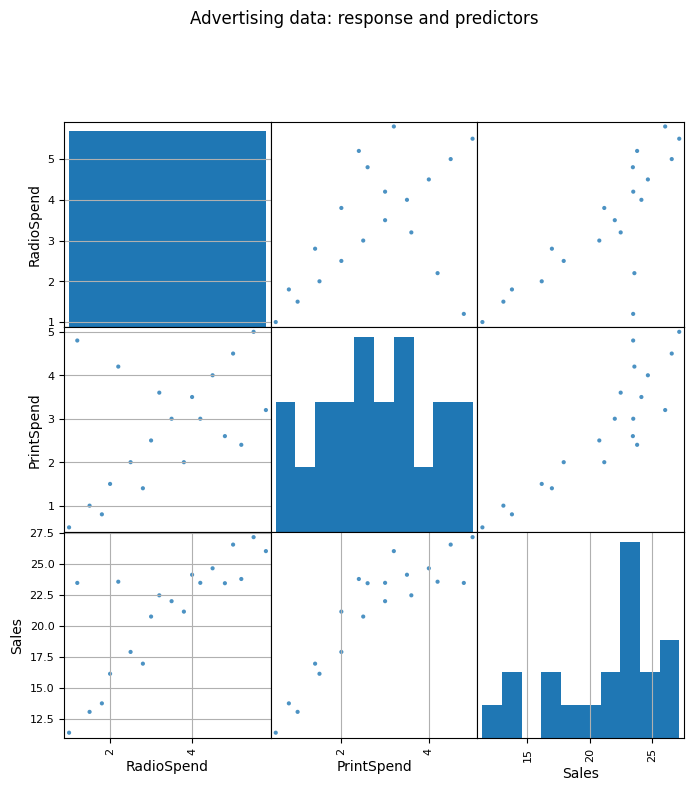

In [3]:
axes = pd.plotting.scatter_matrix(ads, figsize=(8, 8), diagonal="hist", alpha=0.8)
plt.suptitle("Advertising data: response and predictors", y=1.02)
plt.show()

## First Fit

The formula syntax below says: use `Sales` as the response and use both `RadioSpend` and `PrintSpend` as predictors.

In [4]:
model = smf.ols("Sales ~ RadioSpend + PrintSpend", data=ads).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     224.5
Date:                Mon, 18 May 2026   Prob (F-statistic):           6.00e-13
Time:                        01:53:51   Log-Likelihood:                -25.465
No. Observations:                  20   AIC:                             56.93
Df Residuals:                      17   BIC:                             59.92
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.7542      0.583     16.731      0.0

Read the fitted equation as

$$\widehat{Sales}=b_0+b_1(RadioSpend)+b_2(PrintSpend).$$

`RadioSpend` and `PrintSpend` are not separate one-variable explanations. The coefficient for `RadioSpend` is interpreted while holding `PrintSpend` fixed. The coefficient for `PrintSpend` is interpreted while holding `RadioSpend` fixed.

In [5]:
params = model.params
print(
    f"Fitted equation: Sales-hat = {params['Intercept']:.3f} "
    f"+ {params['RadioSpend']:.3f} RadioSpend "
    f"+ {params['PrintSpend']:.3f} PrintSpend"
)

Fitted equation: Sales-hat = 9.754 + 1.465 RadioSpend + 2.303 PrintSpend


## Transfer Prompt

Before using multiple regression on another problem, write down three things:

- response variable and units;
- candidate predictors and units;
- which coefficient interpretations require holding other predictors fixed.
